Goals of this experiment: Implement and explain bottom up merge sort, an iterative implementation instead of a recursive one. Then, we will compare the runtimes of the old implementation with our new bottom up implementation, and explain with graphing what we learned.

In [1]:
from auxilary.bad_sorts import create_random_list
from auxilary.good_sorts import merge, mergesort
import matplotlib.pyplot as plt
import timeit
import gc

In [2]:
def bottom_up_mergesort(L):
    # track the width of adding, shift a sliding window of that width, marge as we go
    width = 1
    while width < len(L):
        for i in range (0, len(L), 2 * width):
            # slicing will automatically handle when we fall off the end, each left or right will continue until we get the end of the list
            # could be short or long or 0, always works with our merge implementation
            left = L[i : i + width]
            right = L[i + width : i + 2 * width]
            L[i : i + 2 * width] = merge(left, right)
        width *= 2

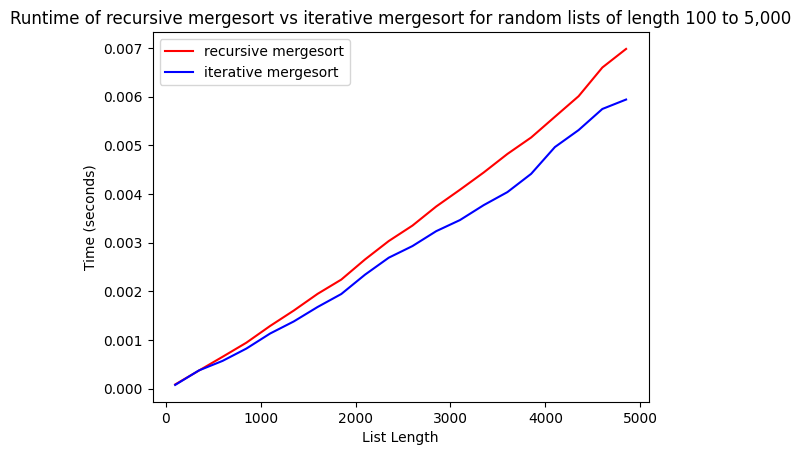

In [4]:
# intiialise lists of fixed lengths for now
# Create a list of lengths from 100 to 5,000 with a step of 250
lengths = list(range(100, 5000, 250))
lists = [create_random_list(l, 100000) for l in lengths]

# for each list we will time it, graph the times
n = len(lists)
times_og, times_new = [], []
# tests per list, take the best occurence
trials = 50
for i in range(n):
    best1, best2 = float('inf'), float('inf')

    gc.disable()
    for _ in range(trials):
        l1 = lists[i][:]
        start = timeit.default_timer()
        mergesort(l1)
        elapsed = timeit.default_timer() - start
        best1 = min(best1, elapsed)
    gc.enable()

    gc.disable()
    for _ in range(trials):
        l1 = lists[i][:]
        start = timeit.default_timer()
        bottom_up_mergesort(l1)
        elapsed = timeit.default_timer() - start
        best2 = min(best2, elapsed)
    gc.enable()

    times_og.append(best1)
    times_new.append(best2)

plt.plot(lengths, times_og, color='red')
plt.plot(lengths, times_new, color='blue')
plt.legend(['recursive mergesort', 'iterative mergesort'])
plt.xlabel('List Length')
plt.ylabel('Time (seconds)')
plt.title('Runtime of recursive mergesort vs iterative mergesort for random lists of length 100 to 5,000')
plt.show()